<a href="https://colab.research.google.com/github/Kartikiscalm/IML-LAB-/blob/labs/Lab5_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: K-Nearest Neighbours
**Course:** Introduction to Machine Learning

---

### How to use this notebook

* Read every **Markdown** cell before running the **Code** cell below it.
* Run cells **in order** (top to bottom). Later cells depend on variables created earlier.
* Cells marked ** EXERCISE** or containing `TODO` markers are where *you* write code.
* These exercises are **woven throughout the notebook** — you must complete each one before moving on,
  because later cells may depend on your work.
* Answer every **Question** in the text cell provided. Your reasoning matters as much as your code.

> In Colab: run a cell with `Shift + Enter`. If something breaks, use *Runtime → Restart and run all*.

---

### Learning Objectives

By the end of this lab you should be able to:

1. **Explain the intuition behind K-Nearest Neighbours (KNN)** and how it differs from parametric models like logistic regression.
2. **Describe the role of K** and explain the bias-variance trade-off as K changes.
3. **Explain why feature scaling is essential for KNN** and apply it correctly without data leakage.
4. **Train and evaluate a KNN classifier** with scikit-learn on both synthetic and real data.

---

### Prerequisites

Python basics, NumPy, Pandas, Matplotlib, train/test split, feature scaling, basic classification concepts (from Labs 3 & 4).

---

**IMPORTANT Submission Information**

Create a copy of this notebook before writing your code.
The ToDo cells must be completed and submitted via the course portal.
This submission is important because in absence of this your assignment won't be evaluated.


### Setup

Run this cell first. Everything below depends on it.

In [ ]:
# --- Core libraries -----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- A fixed random seed makes your results reproducible ------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Nicer default plots --------------------------------------------------
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3

pd.set_option("display.width", 120)

print("Setup complete.")
print("NumPy:", np.__version__, "| Pandas:", pd.__version__)


Setup complete.
NumPy: 2.1.3 | Pandas: 2.2.3


---
# PART A — CONCEPTUAL INTRODUCTION
---

## 2. What is K-Nearest Neighbours?

K-Nearest Neighbours (KNN) is one of the simplest and most intuitive algorithms in machine learning.
Its core idea can be expressed in one sentence:

> **To classify a new point, look at the K training points closest to it and take a majority vote.**

Unlike logistic regression — which learns a fixed set of weights ($\beta$) during training — KNN does
**not learn any parameters**. Instead, it memorises the entire training set and defers all computation
to prediction time. This makes it a **lazy learner** (or **instance-based learner**).

### How a prediction is made

Given a query point $x_{\text{new}}$:

1. **Compute the distance** from $x_{\text{new}}$ to every training point.
2. **Find the K nearest** training points (the "neighbourhood").
3. **Take a majority vote** among their labels to produce a predicted class.

The most common distance measure is **Euclidean distance**:

$$d(x, x') = \sqrt{\sum_{j=1}^{p}(x_j - x'_j)^2}$$

where $p$ is the number of features.

### A quick analogy

Imagine you move to a new city and want to know the vibe of your neighbourhood. You ask your
**5 nearest neighbours** about their commute, lifestyle, etc. You do not build a global model of the
city — you use the people immediately around you. That is KNN.

| Property | KNN | Logistic Regression |
|---|---|---|
| Training time | Instant (just store data) | Iterative optimisation |
| Prediction time | Slow (scan all training points) | Fast (matrix multiply) |
| Model parameters | None (non-parametric) | Learned weights $\beta$ |
| Decision boundary | Flexible, non-linear | Always a straight line |
| Interpretability | Intuitive ("similar examples") | Coefficients have meaning |

### 🧠 Question 2.1 — KNN fundamentals

> **(a)** KNN is called a "lazy learner." What does lazy mean in this context? Is being lazy always a disadvantage?
>
> **(b)** If you use K=1, the model will always classify any training point correctly. Why does this not mean the model is perfect?
>
> **(c)** Think about a dataset with 10,000 training points and 50 features. What potential challenge does KNN face at prediction time compared to logistic regression?

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...


## 3. Distance: The Engine of KNN

Before training any model, let us build intuition about distance — specifically, Euclidean distance —
by computing it manually and seeing how it behaves.


Distance to A: 2.8284
Distance to B: 1.1180
Distance to C: 3.6056
Nearest neighbour: B


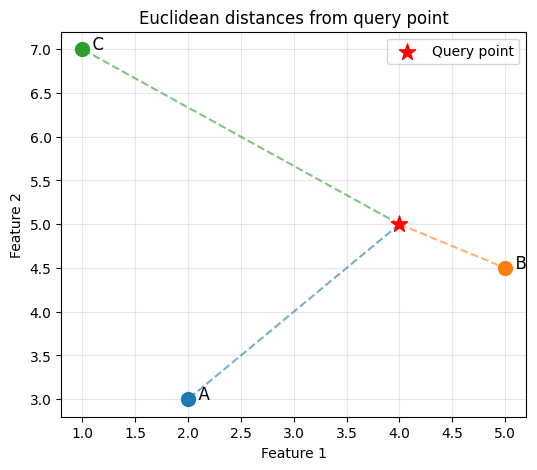

In [ ]:
# A small 2D example: which point is closest to the query?
query   = np.array([4.0, 5.0])
point_A = np.array([2.0, 3.0])
point_B = np.array([5.0, 4.5])
point_C = np.array([1.0, 7.0])

def euclidean(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

dist_A = euclidean(query, point_A)
dist_B = euclidean(query, point_B)
dist_C = euclidean(query, point_C)

print(f"Distance to A: {dist_A:.4f}")
print(f"Distance to B: {dist_B:.4f}")
print(f"Distance to C: {dist_C:.4f}")

nearest = min(zip([dist_A, dist_B, dist_C], ["A", "B", "C"]), key=lambda x: x[0])
print(f"Nearest neighbour: {nearest[1]}")

# Visualise
fig, ax = plt.subplots(figsize=(6, 5))
for pt, label, col in [(point_A, "A", "tab:blue"),
                        (point_B, "B", "tab:orange"),
                        (point_C, "C", "tab:green")]:
    ax.scatter(*pt, s=100, color=col, zorder=5)
    ax.annotate(f"  {label}", pt, fontsize=12)
    ax.plot([query[0], pt[0]], [query[1], pt[1]], ls="--", color=col, alpha=0.6)

ax.scatter(*query, s=150, marker="*", color="red", zorder=6, label="Query point")
ax.legend()
ax.set_title("Euclidean distances from query point")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
plt.show()


### ✍️ EXERCISE 1 — Computing Distances

The table below lists five training points and their classes.

| Point | Feature 1 | Feature 2 | Class |
|---|---|---|---|
| P1 | 1.0 | 2.0 | A |
| P2 | 3.0 | 4.0 | B |
| P3 | 5.0 | 1.0 | A |
| P4 | 2.0 | 5.0 | B |
| P5 | 4.0 | 3.0 | A |

A new query point has coordinates **(3.0, 3.0)**.

**Part (a) — By hand:** Compute the Euclidean distance from the query to **P1** and **P2** using the
formula. Show your working.

**Part (b) — In Python:** Complete the code below to compute distances to all five points and predict
the class using K=3.


In [ ]:
# ===================== EXERCISE 1 =======================

training_points = np.array([[1.0, 2.0],
                             [3.0, 4.0],
                             [5.0, 1.0],
                             [2.0, 5.0],
                             [4.0, 3.0]])
training_labels = np.array(["A", "B", "A", "B", "A"])
query_point = np.array([3.0, 3.0])

# TODO 1: compute the Euclidean distance from query_point to EACH training point.
#         Store the result in a NumPy array called `distances`.
# distances = ...

# TODO 2: find the indices of the 3 nearest neighbours (smallest distances).
#         Hint: np.argsort(distances)[:3]
# nearest_indices = ...

# TODO 3: retrieve the labels of those 3 neighbours.
# nearest_labels = ...

# TODO 4: take a majority vote to predict the class.
#         Hint: use a Counter or pd.Series(nearest_labels).value_counts()
# from collections import Counter
# prediction = ...

# TODO 5: print the distances, nearest labels, and predicted class.
# print("Distances    :", np.round(distances, 4))
# print("3 nearest labels:", nearest_labels)
# print("Predicted class  :", prediction)


### Part (c) — Questions

> **1.** Which two points are equidistant from the query? What problem can this cause in a tie-breaking vote?
> **2.** Repeat the prediction mentally with K=1 and K=5. Do the answers change? Why or why not?
> **3.** If Feature 1 were measured in metres and Feature 2 in kilometres, would the distances still be meaningful? What would happen to predictions?

✍️ **Your answers:**

1. ...
2. ...
3. ...


## 4. Why Feature Scaling is Critical for KNN

This is not optional background — it is a **prerequisite** for using KNN correctly.

Euclidean distance adds up squared differences across all features. If one feature is measured in large
units and another in small units, the large-unit feature will dominate the distance calculation,
effectively making the other features irrelevant to the algorithm.

Consider two features:
- `income` in rupees: ranges from ₹20,000 to ₹1,20,000
- `age` in years: ranges from 18 to 65

A difference of 1 year in age contributes **1** to the squared distance.
A difference of ₹1,000 in income contributes **1,000,000**.
The distance is entirely determined by income, and age is invisible.

After **standardisation** (mean 0, std 1), every feature contributes on an equal footing.

> ⚠️ **Rule**: Always scale features before training KNN. Fit the scaler on the training set only.


In [ ]:
# Demonstration: KNN ignores a feature when scales differ wildly
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

rng_scale = np.random.default_rng(RANDOM_STATE)
n = 200

age_raw    = rng_scale.uniform(18, 65, n)
income_raw = rng_scale.uniform(20000, 120000, n)

# True rule: both features matter equally (in standardised units)
age_s    = (age_raw - age_raw.mean()) / age_raw.std()
income_s = (income_raw - income_raw.mean()) / income_raw.std()
labels   = (age_s + income_s > 0).astype(int)

X_raw = np.column_stack([age_raw, income_raw])
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_raw, labels, test_size=0.3, random_state=RANDOM_STATE)

# KNN WITHOUT scaling
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_tr_r, y_tr_r)
acc_raw = knn_raw.score(X_te_r, y_te_r)

# KNN WITH scaling (fit on training data only)
sc = StandardScaler()
X_tr_s_demo = sc.fit_transform(X_tr_r)
X_te_s_demo = sc.transform(X_te_r)

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_tr_s_demo, y_tr_r)
acc_scaled = knn_scaled.score(X_te_s_demo, y_te_r)

print(f"KNN (no scaling)   — Test accuracy: {acc_raw:.4f}")
print(f"KNN (with scaling) — Test accuracy: {acc_scaled:.4f}")
print(f"Improvement from scaling: {acc_scaled - acc_raw:.4f}")


KNN (no scaling)   — Test accuracy: 0.6667
KNN (with scaling) — Test accuracy: 0.9667
Improvement from scaling: 0.3000


### 🧠 Question 4.1 — Scaling and KNN

> **(a)** In the demonstration above, why does the unscaled KNN perform worse? Which feature is dominating the distance computation?
>
> **(b)** Would scaling matter as much for logistic regression? Recall from Lab 3 that scaling helps convergence but does not change the decision boundary. What is fundamentally different about KNN?
>
> **(c)** A student applies StandardScaler to the full dataset (train + test combined) before splitting. Is this acceptable? What rule does it violate?

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...


---
# PART B — CHOOSING K: THE BIAS-VARIANCE TRADE-OFF
---

## 5. The Effect of K

K is the single most important hyperparameter in KNN. Choosing it well is non-trivial.

| Small K (e.g. K=1) | Large K (e.g. K=N) |
|---|---|
| Decision boundary is very wiggly | Decision boundary is very smooth |
| Fits training data almost perfectly | Ignores local structure |
| **High variance** — sensitive to noise | **High bias** — ignores relevant patterns |
| Likely to **overfit** | Likely to **underfit** |

This is the classic **bias-variance trade-off**: as K increases, variance decreases but bias increases.
The right K balances the two.

A practical strategy is to try many values of K and choose the one that minimises the **validation error**.


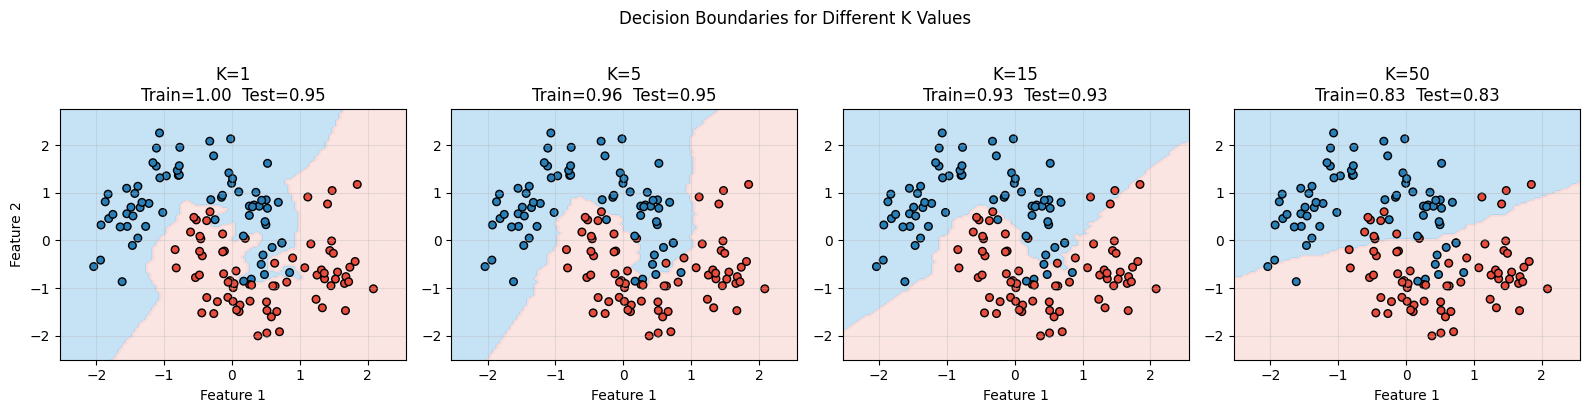

In [ ]:
# Visualise decision boundaries for different values of K
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(n_samples=200, noise=0.25, random_state=RANDOM_STATE)
X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(
    X_moon, y_moon, test_size=0.3, random_state=RANDOM_STATE)

sc_m = StandardScaler()
X_m_tr_s = sc_m.fit_transform(X_m_tr)
X_m_te_s = sc_m.transform(X_m_te)

k_values = [1, 5, 15, 50]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

h = 0.05
x0_min, x0_max = X_m_tr_s[:, 0].min() - 0.5, X_m_tr_s[:, 0].max() + 0.5
x1_min, x1_max = X_m_tr_s[:, 1].min() - 0.5, X_m_tr_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))

cmap_light = ListedColormap(["#AED6F1", "#FADBD8"])
cmap_bold  = ListedColormap(["#2980B9", "#E74C3C"])

for ax, k in zip(axes, k_values):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_m_tr_s, y_m_tr)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.7)
    ax.scatter(X_m_tr_s[:, 0], X_m_tr_s[:, 1],
               c=y_m_tr, cmap=cmap_bold, edgecolor="k", s=30)
    tr_acc = clf.score(X_m_tr_s, y_m_tr)
    te_acc = clf.score(X_m_te_s, y_m_te)
    ax.set_title(f"K={k}\nTrain={tr_acc:.2f}  Test={te_acc:.2f}")
    ax.set_xlabel("Feature 1")

axes[0].set_ylabel("Feature 2")
plt.suptitle("Decision Boundaries for Different K Values", y=1.02)
plt.tight_layout()
plt.show()


### ✍️ EXERCISE 2 — Finding the Best K

Complete the code below to systematically search for the best K on a dataset using a validation approach.


In [ ]:
# ===================== EXERCISE 2 =======================
from sklearn.datasets import make_classification

X_ex2, y_ex2 = make_classification(
    n_samples=300, n_features=4, n_informative=3,
    n_redundant=1, random_state=RANDOM_STATE)

# TODO 1: split into train+val (80%) and final test (20%).
#         Then split the 80% further into 75% train / 25% val.
#         Use random_state=RANDOM_STATE and stratify=y_ex2 in both splits.
# X_temp, X_test_ex2, y_temp, y_test_ex2 = train_test_split(...)
# X_train_ex2, X_val_ex2, y_train_ex2, y_val_ex2 = train_test_split(...)

# TODO 2: scale the features. Fit on training data only.
#         Apply the same scaler to val and test sets.
# scaler_ex2 = StandardScaler()
# X_train_s = scaler_ex2.fit_transform(X_train_ex2)
# X_val_s   = scaler_ex2.transform(X_val_ex2)
# X_test_s  = scaler_ex2.transform(X_test_ex2)

# TODO 3: loop over k in range(1, 31) and record validation accuracy for each k.
# k_range = range(1, 31)
# val_accs = []
# for k in k_range:
#     knn_k = KNeighborsClassifier(n_neighbors=k)
#     knn_k.fit(X_train_s, y_train_ex2)
#     val_accs.append(knn_k.score(X_val_s, y_val_ex2))

# TODO 4: plot validation accuracy vs. K.
# plt.plot(k_range, val_accs, marker="o")
# plt.xlabel("K")
# plt.ylabel("Validation accuracy")
# plt.title("Choosing K by Validation Accuracy")
# plt.show()

# TODO 5: select the best K and evaluate it on the TEST set (only once).
# best_k = list(k_range)[np.argmax(val_accs)]
# final_knn = KNeighborsClassifier(n_neighbors=best_k)
# final_knn.fit(X_train_s, y_train_ex2)
# test_acc_ex2 = final_knn.score(X_test_s, y_test_ex2)
# print(f"Best K: {best_k}  |  Test accuracy: {test_acc_ex2:.4f}")


### 🧠 Question 5.1 — Interpreting the K search

> **(a)** Looking at the plot of validation accuracy vs. K: where is the model overfitting and where is it underfitting? How can you tell from the curve?
>
> **(b)** Why do we evaluate the *final* test accuracy only once, using the best K? What would go wrong if we used the test set to choose K?
>
> **(c)** Even K values often avoid ties in binary classification. Should you always prefer even K? What if there are 3 classes?

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...


---
# PART C — A REAL DATASET: HEART DISEASE CLASSIFICATION
---

## 6. The Dataset

We will use a synthetic but realistic dataset that mimics a **heart disease screening** scenario.
Each row represents a patient with the following features:

| Feature | Description |
|---|---|
| `age` | Age in years |
| `resting_bp` | Resting blood pressure (mm Hg) |
| `cholesterol` | Serum cholesterol (mg/dL) |
| `max_heart_rate` | Maximum heart rate achieved |
| `oldpeak` | ST depression induced by exercise |
| `chest_pain` | Chest pain type (0–3) |

**Target:** `heart_disease` — 1 = disease present, 0 = disease absent.

This is a **binary classification** problem. As with the cancer dataset in Lab 3, class 1 (disease
present) is the clinically important event — and the two types of error have very different real-world costs.


In [ ]:
# Generate the synthetic heart disease dataset
rng_h = np.random.default_rng(77)
n_pat = 400

age_h        = rng_h.integers(30, 80, n_pat)
resting_bp   = rng_h.normal(130, 18, n_pat).clip(90, 200).round(0)
cholesterol  = rng_h.normal(240, 50, n_pat).clip(150, 400).round(0)
max_hr       = rng_h.normal(150, 25, n_pat).clip(70, 202).round(0)
oldpeak      = rng_h.gamma(1.5, 1.0, n_pat).clip(0, 6.2).round(1)
chest_pain   = rng_h.choice([0, 1, 2, 3], n_pat, p=[0.4, 0.2, 0.2, 0.2])

true_z_h = (-4.0 + 0.04 * age_h + 0.015 * resting_bp
            - 0.005 * max_hr + 0.35 * oldpeak + 0.30 * chest_pain)
true_p_h = 1 / (1 + np.exp(-true_z_h))
heart_disease = rng_h.binomial(1, true_p_h)

heart_df = pd.DataFrame({
    "age":            age_h,
    "resting_bp":     resting_bp,
    "cholesterol":    cholesterol,
    "max_heart_rate": max_hr,
    "oldpeak":        oldpeak,
    "chest_pain":     chest_pain,
    "heart_disease":  heart_disease
})

print("Shape:", heart_df.shape)
print("\nClass distribution:")
print(heart_df["heart_disease"].value_counts().sort_index())
print("\nMissing values:", heart_df.isna().sum().sum())
heart_df.head(8)


Shape: (400, 7)

Class distribution:
heart_disease
0    174
1    226
Name: count, dtype: int64

Missing values: 0


,age,resting_bp,cholesterol,max_heart_rate,oldpeak,chest_pain,heart_disease
0,32,145.0,330.0,125.0,1.5,2,0
1,69,126.0,299.0,125.0,0.8,2,1
2,61,120.0,290.0,80.0,2.3,1,1
3,57,133.0,240.0,165.0,1.5,2,1
4,69,154.0,243.0,164.0,1.4,3,1
5,42,118.0,287.0,119.0,5.1,0,1
6,73,122.0,244.0,136.0,2.1,1,1
7,46,117.0,266.0,153.0,0.4,2,0


### ✍️ EXERCISE 3 — Explore the Dataset

Before training any model, always explore the data visually and numerically.

In [ ]:
# ===================== EXERCISE 3 =======================

# TODO 1: print summary statistics for each feature (use .describe())
# display(heart_df.describe().round(2))

# TODO 2: create a scatter plot of age vs. max_heart_rate, coloured by heart_disease.
#         Use different markers for each class and add a legend.
# sick    = heart_df[heart_df["heart_disease"] == 1]
# healthy = heart_df[heart_df["heart_disease"] == 0]
# plt.scatter(healthy["age"], healthy["max_heart_rate"], marker="o",
#             c="tab:blue", label="No disease", edgecolor="k", s=40)
# plt.scatter(sick["age"],    sick["max_heart_rate"],    marker="^",
#             c="tab:red",  label="Disease",    edgecolor="k", s=40)
# plt.xlabel("Age"); plt.ylabel("Max Heart Rate")
# plt.title("Age vs. Max Heart Rate by Heart Disease Status")
# plt.legend(); plt.show()

# TODO 3: plot histograms of `oldpeak` for each class on the same axes.
# for cls, label, colour in [(0, "No disease", "tab:blue"), (1, "Disease", "tab:red")]:
#     plt.hist(heart_df[heart_df["heart_disease"] == cls]["oldpeak"],
#              bins=20, alpha=0.6, label=label, color=colour, edgecolor="k")
# plt.xlabel("Oldpeak (ST depression)")
# plt.ylabel("Count")
# plt.title("Oldpeak distribution by class")
# plt.legend(); plt.show()


### 🧠 Question 6.1 — Data exploration

> **(a)** From the scatter plot: does max heart rate appear to separate the two classes? In which direction (higher or lower max_hr is more associated with disease)?
>
> **(b)** Look at the oldpeak histograms. Which class tends to have higher oldpeak values? Does this match the positive coefficient in the true data-generating formula?
>
> **(c)** The class balance is not exactly 50/50. What is the approximate split? Would a model that always predicts the majority class be a useful baseline here?

✍️ **Your answers:**

(a) ...
(b) ...
(c) ...


## 7. Training the KNN Classifier

We now apply the full workflow: **split → scale → train → predict**.

The golden rule from Labs 3 and 4 applies here with extra urgency for KNN:
**if you do not scale, the features with the largest numerical range will dominate the distance
calculation and you will get poor predictions**.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ---- Features and target -------------------------------------------------
X_heart = heart_df.drop(columns="heart_disease").values
y_heart = heart_df["heart_disease"].values

# ---- Train/test split (stratified) ----------------------------------------
X_h_tr, X_h_te, y_h_tr, y_h_te = train_test_split(
    X_heart, y_heart,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_heart
)

# ---- Scale (fit on training data ONLY) -------------------------------------
scaler_h = StandardScaler()
X_h_tr_s = scaler_h.fit_transform(X_h_tr)
X_h_te_s = scaler_h.transform(X_h_te)

# ---- Train KNN (K=7) -------------------------------------------------------
knn_heart = KNeighborsClassifier(n_neighbors=7)
knn_heart.fit(X_h_tr_s, y_h_tr)

# ---- Evaluate ---------------------------------------------------------------
train_acc = knn_heart.score(X_h_tr_s, y_h_tr)
test_acc  = knn_heart.score(X_h_te_s, y_h_te)

print(f"Training accuracy: {train_acc:.4f}")
print(f"Test accuracy    : {test_acc:.4f}")
print(f"Gap (train-test) : {train_acc - test_acc:.4f}")


Training accuracy: 0.6267
Test accuracy    : 0.6200
Gap (train-test) : 0.0067
